<a href="https://colab.research.google.com/github/charlesloveth002-a11y/Python_basics/blob/main/SWEP_200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning with Google Colab
A beginner-to-practical lecture for 200-level
SWEP students
Reaction Engineering: Reactor Conversion
Random Forest Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_excel ("/content/reactor_conversion_training_data (1).xlsx")

In [4]:
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 6)


,Temperature_C,Residence_Time_min,Catalyst_wt_pct,Initial_Conc_M,Pressure_atm,Conversion_pct
0,144.9,12.7,1.38,2.9,7.9,0.7
1,214.1,33.4,1.31,3.3,10.9,12.0
2,187.8,52.6,4.54,1.4,9.1,23.6
3,171.8,44.5,1.32,2.7,8.8,12.0
4,118.7,48.8,1.43,2.5,5.7,4.6


Investigating missing data and data types

In [5]:
print("Data Types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSummary Statistics:")
display(df.describe())
print("Duplicate rows:",
df.duplicated().sum())

Data Types:
Temperature_C         float64
Residence_Time_min    float64
Catalyst_wt_pct       float64
Initial_Conc_M        float64
Pressure_atm          float64
Conversion_pct        float64
dtype: object

Missing values per column:
Temperature_C         15
Residence_Time_min    24
Catalyst_wt_pct       22
Initial_Conc_M        25
Pressure_atm           0
Conversion_pct         0
dtype: int64

Summary Statistics:


,Temperature_C,Residence_Time_min,Catalyst_wt_pct,Initial_Conc_M,Pressure_atm,Conversion_pct
count,985.000000,976.000000,978.000000,975.000000,1000.000000,1000.000000
mean,157.549543,31.406660,2.556125,2.209436,12.894300,9.011000
std,39.508256,16.934247,1.423482,1.003481,70.025169,11.955022
min,-99.000000,2.300000,0.100000,0.500000,4.200000,0.000000
25%,127.500000,16.000000,1.380000,1.300000,6.400000,3.100000
50%,159.300000,32.050000,2.545000,2.200000,7.950000,7.000000
75%,189.300000,46.100000,3.820000,3.100000,9.400000,12.100000
max,220.000000,60.000000,4.990000,4.000000,999.900000,150.000000


Duplicate rows: 0


Clean data set

In [16]:
df_clean = df.copy()
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Temperature_C         0
Residence_Time_min    0
Catalyst_wt_pct       0
Initial_Conc_M        0
Pressure_atm          0
Conversion_pct        0
dtype: int64


Outlier

In [20]:
def replace_outliers_with_median(dataframe, columns):
    data = dataframe.copy()
    report = []
    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (data[column] < lower) | (data[column] > upper)
        n_outliers = int(mask.sum())
        data.loc[mask, column] = data[column].median()
        report.append({
            "Column": column,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outliers_Replaced": n_outliers
        })
    return data, pd.DataFrame(report)

df_clean, outlier_report = replace_outliers_with_median(df_clean, numeric_columns.tolist())
display(outlier_report)

,Column,Lower_Bound,Upper_Bound,Outliers_Replaced
0,Temperature_C,39.1500,278.1500,0
1,Residence_Time_min,-27.7625,89.9375,0
2,Catalyst_wt_pct,-2.1500,7.3700,0
3,Initial_Conc_M,-1.0000,5.4000,0
4,Pressure_atm,1.9000,13.9000,0
5,Conversion_pct,-9.6500,24.3500,1


Download clean data

In [21]:
df_clean.to_excel("cleaned_data.xlsx",
index=False)
from google.colab import files
files.download("cleaned_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exploratory Data Analysis — Correlation Matrix
Calculate the Pearson correlation matrix and plot a
heatmap

,Temperature_C,Residence_Time_min,Catalyst_wt_pct,Initial_Conc_M,Pressure_atm,Conversion_pct
Temperature_C,1.000,0.033,0.012,-0.033,0.948,0.486
Residence_Time_min,0.033,1.000,0.027,-0.019,0.039,0.610
Catalyst_wt_pct,0.012,0.027,1.000,-0.024,0.025,0.260
Initial_Conc_M,-0.033,-0.019,-0.024,1.000,-0.041,-0.031
Pressure_atm,0.948,0.039,0.025,-0.041,1.000,0.488
Conversion_pct,0.486,0.610,0.260,-0.031,0.488,1.000


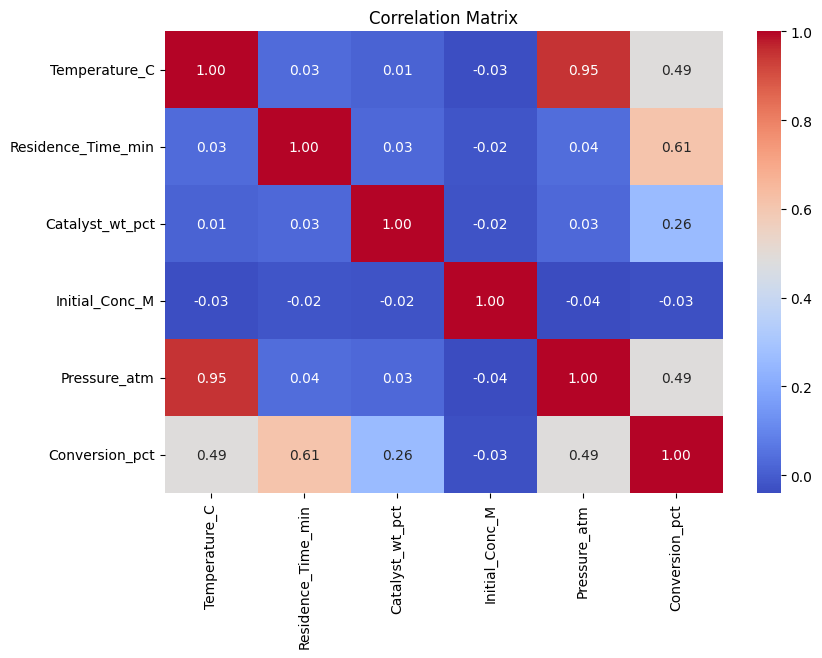

In [22]:
corr = df_clean.corr(numeric_only=True)
display(corr.round(3))
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f",
cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Define Features, Target, and Split Data (700/300)
Separate into feature set X and target y (Conversion_pct), then create a 700 training / 300 testing split with
random_state=42

In [24]:
from sklearn.model_selection import train_test_split
features = [
"Temperature_C",
"Residence_Time_min",
"Catalyst_wt_pct",
"Initial_Conc_M",
"Pressure_atm"
]
target = "Conversion_pct"
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(
X, y,
train_size=700,
test_size=300,
random_state=42,
shuffle=True
)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (700, 5), X_test shape: (300, 5)
y_train shape: (700,), y_test shape: (300,)


Train the Random Forest Regressor Model
Initialize RandomForestRegressor with 200 trees (n_estimators=200) and fit on the 700 training samples

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


Evaluate Performance (MAE, RMSE, R²)
Generate predictions for the 300 test samples and compute regression metrics

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R² = {r2:.3f}")

MAE = 2.245
RMSE = 2.877
R² = 0.764


Visualize Actual vs. Predicted & Residuals
Plot performance visualizations to evaluate model fit and error distribution

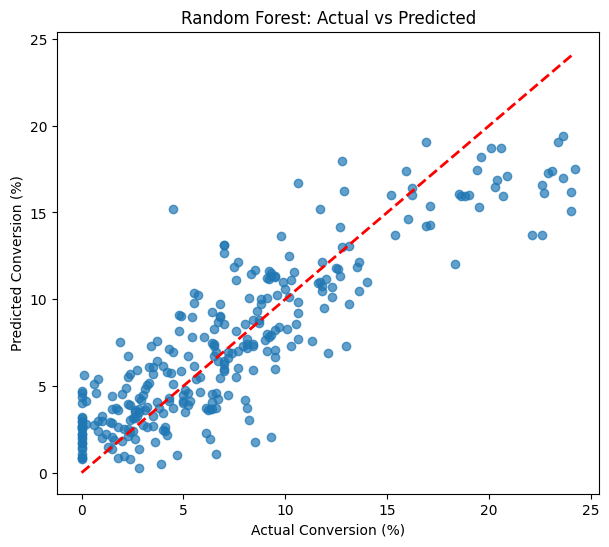

In [34]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Conversion (%)")
plt.ylabel("Predicted Conversion (%)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

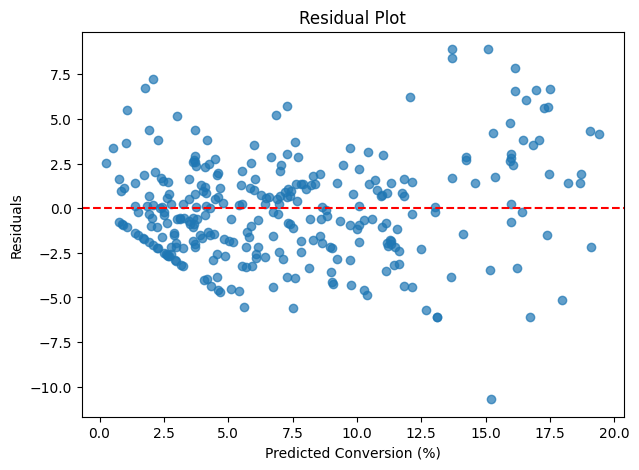

In [35]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Conversion (%)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Feature Importance Analysis
Extract and chart feature importances

,Importance
Residence_Time_min,0.454512
Temperature_C,0.189389
Pressure_atm,0.187337
Catalyst_wt_pct,0.130284
Initial_Conc_M,0.038478


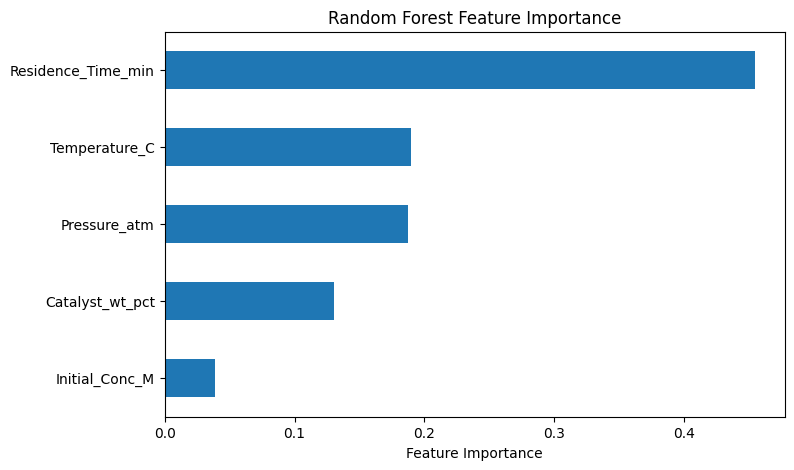

In [36]:
importance = pd.Series(
rf_model.feature_importances_,
index=features
).sort_values(ascending=False)
display(importance.to_frame("Importance"))
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

Predict a New Reactor Condition
Test a new single set of operating parameters

In [37]:
new_condition = pd.DataFrame({
"Temperature_C": [178.0],
"Residence_Time_min": [42.0],
"Catalyst_wt_pct": [1.2],
"Initial_Conc_M": [4.0],
"Pressure_atm": [7.0]
})
predicted_conversion = rf_model.predict(new_condition)
print(f"Predicted Conversion = {predicted_conversion[0]:.2f}%")

Predicted Conversion = 11.68%
